In [1]:
import os
import os.path as op

import matplotlib.pyplot as plt
import nibabel as nib
import plotly

from AFQ.api.participant import ParticipantAFQ
import AFQ.data.fetch as afd
import AFQ.definitions.image as afm


In [ ]:
# done
afd.fetch_hbn_preproc(["NDARAA948VFH"])

## Defining data files
If your data is not in BIDS format, you can still use pyAFQ. If you have BIDS compliant dataset, you can use GroupAFQ instead (:doc:plot_001_group_afq_api). Otherwise, You will need to define the data files that you want to use. In this case, we will define the data files for the subject we downloaded above. The data files are located in the ~/AFQ_data/HBN/derivatives/qsiprep directory, and are organized into a BIDS compliant directory structure. The data files are located in the dwi directories.



In [2]:
sub_dir = op.join(afd.afq_home, "HBN", "derivatives", "qsiprep",
                   "sub-NDARAA948VFH")
dwi_data_file = op.join(sub_dir, "ses-HBNsiteRU", "dwi", (
    "sub-NDARAA948VFH_"
    "ses-HBNsiteRU_"
    "acq-64dir_space-T1w_desc-preproc_dwi.nii.gz"))
bval_file = op.join(sub_dir, "ses-HBNsiteRU", "dwi", (
    "sub-NDARAA948VFH_"
    "ses-HBNsiteRU_"
    "acq-64dir_space-T1w_desc-preproc_dwi.bval"))
bvec_file = op.join(sub_dir, "ses-HBNsiteRU", "dwi", (
    "sub-NDARAA948VFH_"
    "ses-HBNsiteRU_"
    "acq-64dir_space-T1w_desc-preproc_dwi.bvec"))
t1_file = op.join(sub_dir, "anat",
                  "sub-NDARAA948VFH_desc-preproc_T1w.nii.gz")

# You will also need to define the output directory where you want to store the
# results. The output directory needs to exist before exporting ParticipantAFQ
# results.

output_dir = op.join(afd.afq_home, "HBN",
                     "derivatives", "afq", "sub-NDARAA948VFH",
                     "ses-HBNsiteRU", "dwi")
os.makedirs(output_dir, exist_ok=True)


## Set tractography parameters (optional)
We make create a `tracking_params` variable, which we will pass to the ParticipantAFQ object which specifies that we want 100,000 seeds randomly distributed in the white matter. We only do this to make this example faster and consume less space; normally, we use more seeds.

In [3]:
tracking_params = dict(n_seeds=1e5,
                       random_seeds=True,
                       rng_seed=2025,
                       trx=True)


## Define PVE images (optional)
To improve segmentation and tractography results, we can provide partial volume estimate (PVE) images for the cerebrospinal fluid (CSF), gray matter (GM), and white matter (WM). Here, we define these images using the `AFQ.definitions.image.PVEImages` class, which takes as input three `AFQ.definitions.image.ImageFile` objects, one for each tissue type. One can also provide a single PVE image with all three tissue types using the `AFQ.definitions.image.PVEImage` class. Finally, by default, if no PVE images are provided, pyAFQ will use **SynthSeg2** to compute these images.



In [4]:
pve = afm.PVEImages(
    afm.ImageFile(
        path=op.join(sub_dir, "anat", 
                     "sub-NDARAA948VFH_label-CSF_probseg.nii.gz")),
    afm.ImageFile(
        path=op.join(sub_dir, "anat", 
                     "sub-NDARAA948VFH_label-GM_probseg.nii.gz")),
    afm.ImageFile(
        path=op.join(sub_dir, "anat", 
                     "sub-NDARAA948VFH_label-WM_probseg.nii.gz")))


## Brain Mask Definition (optional)
By default, pyAFQ will compute a brain mask from the T1. However, this requires onnxruntime to be installed. If you do not have onnxruntime installed, or if you want to use a different brain mask, you can specify it here.



In [5]:
brain_mask_definition = afm.ImageFile(
    path=op.join(sub_dir, "anat", "sub-NDARAA948VFH_desc-brain_mask.nii.gz"))


## Initialize a ParticipantAFQ object:
Creates a ParticipantAFQ object, that encapsulates tractometry. This object can be used to manage the entire `/explanations/index`, including:
- Tractography

- Registration

- Segmentation

- Cleaning

- Profiling

- Visualization

To initialize the object, we will pass in the diffusion data files and specify the output directory where we want to store the results. We will also pass in the tracking parameters we defined above.




In [6]:
myafq = ParticipantAFQ(
    dwi_data_file=dwi_data_file,
    bval_file=bval_file,
    bvec_file=bvec_file,
    t1_file=t1_file,
    output_dir=output_dir,
    tracking_params=tracking_params,
    pve=pve,
    brain_mask_definition=brain_mask_definition,
)


## Calculating DTI FA (Diffusion Tensor Imaging Fractional Anisotropy)
The ParticipantAFQ object has a method called `export`, which allows the user to calculate various derived quantities from the data.

For example, FA can be computed using the DTI model, by explicitly calling `myafq.export("dti_fa")`. This triggers the computation of DTI parameters, and stores the results in the AFQ derivatives directory. In addition, it calculates the FA from these parameters and stores it in a different file in the same directory.



In [7]:
FA_fname = myafq.export("dti_fa")


INFO:AFQ:Calculating _b0ref.nii.gz...
INFO:AFQ:_b0ref.nii.gz completed. Saving to /Users/applejuiceleigh/AFQ_data/HBN/derivatives/afq/sub-NDARAA948VFH/ses-HBNsiteRU/dwi/sub-NDARAA948VFH_ses-HBNsiteRU_acq-64dir_b0ref.nii.gz
INFO:AFQ:Calculating _desc-brain_mask.nii.gz...
INFO:AFQ:Calculating _desc-T1w_mask.nii.gz...
INFO:AFQ:_desc-T1w_mask.nii.gz completed. Saving to /Users/applejuiceleigh/AFQ_data/HBN/derivatives/afq/sub-NDARAA948VFH/ses-HBNsiteRU/dwi/sub-NDARAA948VFH_ses-HBNsiteRU_acq-64dir_desc-T1w_mask.nii.gz
INFO:AFQ:_desc-brain_mask.nii.gz completed. Saving to /Users/applejuiceleigh/AFQ_data/HBN/derivatives/afq/sub-NDARAA948VFH/ses-HBNsiteRU/dwi/sub-NDARAA948VFH_ses-HBNsiteRU_acq-64dir_desc-brain_mask.nii.gz
INFO:AFQ:Calculating _model-tensor_param-diffusivity_dwimap.nii.gz, _model-tensor_param-s0_dwimap.nii.gz...
INFO:AFQ:_model-tensor_param-diffusivity_dwimap.nii.gz completed. Saving to /Users/applejuiceleigh/AFQ_data/HBN/derivatives/afq/sub-NDARAA948VFH/ses-HBNsiteRU/dwi/models

The result of the call to export is the filename of the corresponding FA files.



We will then use nibabel to load the deriviative file and retrieve the data array.



In [8]:
FA_img = nib.load(FA_fname)
FA = FA_img.get_fdata()

## Visualize the result with Matplotlib
At this point FA is an array, and we can use standard Python tools to visualize it or perform additional computations with it.

In this case we are going to take an axial slice halfway through the FA data array and plot using a sequential color map.



(np.float64(-0.5), np.float64(128.5), np.float64(107.5), np.float64(-0.5))

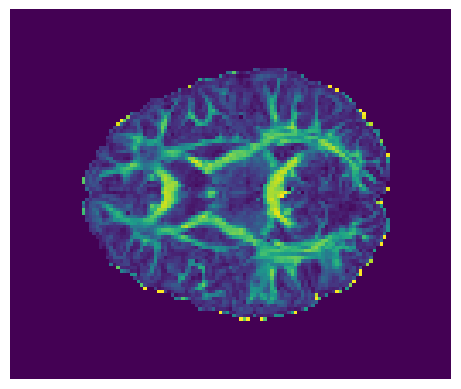

In [9]:
fig, ax = plt.subplots(1)
ax.matshow(FA[:, :, FA.shape[-1] // 2], cmap="viridis")
ax.axis("off")